# MLIP Studio Python API — Google Colab showcase

This notebook installs MLIP Studio using the same custom dependency order documented in the repository, clones the source, installs the API with `--no-deps`, and demonstrates every currently public task API.

Before running it, select **Runtime → Change runtime type → T4 GPU** (or another GPU). The full model stack is large and installation/model downloads can take a while. UMA/eSEN may require prior Hugging Face license approval and login. Individual gated-model sections catch access errors so the rest of the notebook can still run.

Model predictions are examples, not reference-quality scientific results. Always choose a model trained for the relevant chemical/material domain and review its license and citation.

In [1]:
import platform
import shutil
import subprocess
import sys

print("Python:", sys.version)
print("Platform:", platform.platform())
if shutil.which("nvidia-smi"):
    subprocess.run(["nvidia-smi"], check=False)
else:
    print("No NVIDIA GPU detected. The examples will use CPU and may be slow.")

Python: 3.10.9 (tags/v3.10.9:1dd9be6, Dec  6 2022, 20:01:21) [MSC v.1934 64 bit (AMD64)]
Platform: Windows-10-10.0.22631-SP0


## 1. Clone MLIP Studio

In [ ]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/mlipstudio/MLIP-Studio.git"
REPO_DIR = Path("/content/MLIP-Studio")

if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
        check=True,
    )
else:
    print(f"Using existing checkout: {REPO_DIR}")

print("Repository:", REPO_DIR)

## 2. Install system and Python dependencies

These commands intentionally mirror the README/Docker installation order. Several packages are installed with `--no-deps` because their upstream dependency metadata conflicts with the combined MLIP environment.

In [ ]:
!apt-get -qq update
!apt-get -qq install -y build-essential git swig libopenbabel-dev openbabel

In [ ]:
%pip install --upgrade pip
%pip install --no-deps fairchem-core==2.16.0 --ignore-requires-python
%pip install -r /content/MLIP-Studio/requirements.txt
%pip install --no-deps "upet@git+https://github.com/lab-cosmo/upet.git" --ignore-requires-python
%pip install --no-deps "git+https://github.com/WillBaldwin0/graph_electrostatics.git" --ignore-requires-python

## 3. Install the API

Install from the repository root, not from inside the `mlipstudio/` package directory. Editable mode makes notebook code use the cloned source directly.

In [ ]:
%pip install -e /content/MLIP-Studio --no-deps

### Optional Hugging Face login

Set `LOGIN_TO_HUGGING_FACE = True` if you have accepted the UMA/eSEN model terms and want to run the spin-determination example. Colab will display a secure token prompt.

In [ ]:
LOGIN_TO_HUGGING_FACE = False

if LOGIN_TO_HUGGING_FACE:
    from huggingface_hub import notebook_login

    notebook_login()
else:
    print("Skipping Hugging Face login. Set the flag above to run gated models.")

## 4. Import the API and inspect the model catalog

In [2]:
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ase.build import bulk, molecule

import mlipstudio

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("MLIP Studio API:", mlipstudio.__version__)
print("Device:", DEVICE)
print("Installed from:", Path(mlipstudio.__file__).resolve())

def release_unused_resources():
    """Collect objects after the caller deletes its calculator variable."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

MLIP Studio API: 0.1.0.dev0
Device: cuda
Installed from: D:\MLIP_Playground_NEW\GitHub_REPO\mlipstudio\__init__.py


In [3]:
catalog = pd.DataFrame(
    {
        "name": spec.name,
        "family": spec.family,
        "kind": spec.calculator_kind,
        "required_parameters": ", ".join(spec.required_parameters),
    }
    for spec in mlipstudio.list_models()
)
display(catalog)
print(catalog.groupby("family").size())

,name,family,kind,required_parameters
0,MACE MPA Medium,MACE,ase,
1,MACE OMAT Medium,MACE,ase,
2,MACE OMAT Small,MACE,ase,
3,MACE MATPES r2SCAN Medium,MACE,ase,
4,MACE MATPES PBE Medium,MACE,ase,
...,...,...,...,...
58,7net-l3i5,SevenNet,ase,
59,7net-omat,SevenNet,ase,
60,7net-mf-ompa,SevenNet,ase,modal
61,7net-omni,SevenNet,ase,modal


family
FairChem      5
In-House      1
MACE         24
MatterSim     2
ORB          10
SevenNet      5
UPET         16
dtype: int64


## 5. MACE materials workflow

One loaded MACE calculator is reused for single-point prediction, geometry optimization, and cohesive energy. This avoids downloading and loading the same checkpoint repeatedly.

In [4]:
cu = bulk("Cu", crystalstructure="fcc", a=3.62).repeat((2, 2, 2))
mace_calculator = mlipstudio.create_calculator(
    "MACE MPA Medium",
    device=DEVICE,
)
print(cu, mace_calculator.__class__.__name__)

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with C:\Users\Manas\.cache\mace/macempa0mediummodel
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


c:\Users\Manas\AppData\Local\Programs\Python\Python310\lib\site-packages\mace\calculators\mace.py:207: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Atoms(symbols='Cu8', pbc=True, cell=[[0.0, 3.62, 3.62], [3.62, 0.0, 3.62], [3.62, 3.62, 0.0]]) MACECalculator


### 5.1 Single-point energy, forces, and stress

In [5]:
single_point = mlipstudio.SinglePointTask(
    properties=("energy", "forces", "stress"),
)
single_result = single_point.calculate(cu, mace_calculator)

print(f"Energy: {single_result.energy:.6f} eV")
print(f"Maximum force: {single_result.max_force:.6f} eV/Angstrom")
print("Stress (ASE Voigt order, eV/Angstrom^3):", single_result.stress)
print(f"Runtime: {single_result.runtime_seconds:.3f} s")

Energy: -32.796612 eV
Maximum force: 0.000000 eV/Angstrom
Stress (ASE Voigt order, eV/Angstrom^3): [-1.38413627e-02 -1.38413664e-02 -1.38413748e-02  5.22268895e-09
  2.56413712e-09 -2.14053553e-09]
Runtime: 1.060 s


### 5.2 Geometry optimization

In [6]:
distorted_cu = cu.copy()
distorted_cu.positions[0] += [0.10, -0.06, 0.04]

optimization = mlipstudio.OptimizationTask(
    optimizer="LBFGS",
    fmax=0.05,
    steps=30,
    record_trajectory=True,
)
optimization_result = optimization.calculate(distorted_cu, mace_calculator)

print("Converged:", optimization_result.converged)
print("Steps:", optimization_result.steps)
print(f"Final energy: {optimization_result.energy:.6f} eV")
print(f"Final maximum force: {optimization_result.atomic_max_force:.6f} eV/Angstrom")
print("Recorded frames:", len(optimization_result.trajectory))

Converged: True
Steps: 8
Final energy: -32.796150 eV
Final maximum force: 0.046792 eV/Angstrom
Recorded frames: 10


### 5.3 Cohesive energy

For non-FairChem calculators, MLIP Studio evaluates one isolated atom per unique element and records those values in the result. Periodic input selects cohesive energy automatically.

In [7]:
cohesive_result = mlipstudio.AtomizationCohesiveEnergyTask().calculate(
    cu,
    mace_calculator,
)

print("Type:", cohesive_result.calculation_type)
print(f"Cohesive energy: {cohesive_result.cohesive_energy_eV_per_atom:.6f} eV/atom")
print("Reference source:", cohesive_result.reference_source)
print("Isolated-atom references:", cohesive_result.isolated_atom_energies_eV)

Type: cohesive
Cohesive energy: 3.499318 eV/atom
Reference source: calculated-with-system-calculator
Isolated-atom references: {29: -0.600258469581604}


In [8]:
del mace_calculator
release_unused_resources()
print("Released the materials calculator.")

Released the materials calculator.


## 6. HOMO–LUMO gap with the bundled QM9 model

`QM9-Gap` supports non-periodic molecules containing only H, C, N, O, and F. It is packaged with MLIP Studio and does not download a separate checkpoint.

In [9]:
methane = molecule("CH4")
qm9_calculator = mlipstudio.create_calculator("QM9-Gap", device=DEVICE)
gap_result = mlipstudio.HOMOLUMOGapTask().calculate(methane, qm9_calculator)

print(f"Predicted HOMO-LUMO gap: {gap_result.gap_eV:.6f} eV")
print(f"Runtime: {gap_result.runtime_seconds:.3f} s")
del qm9_calculator
release_unused_resources()

Predicted HOMO-LUMO gap: 13.629583 eV
Runtime: 0.042 s


## 7. MACE-POLAR molecular workflow

The MACE-POLAR checkpoint is reused for dipole/partial-charge prediction and molecular atomization energy. Review its Academic Software License before use.

In [10]:
water = molecule("H2O")
polar_calculator = None
try:
    polar_calculator = mlipstudio.create_calculator(
        "MACE POLAR 1 S",
        device=DEVICE,
    )
    print("Loaded MACE POLAR 1 S.")
except Exception as exc:
    print("MACE-POLAR could not be loaded; its two examples will be skipped.")
    print(type(exc).__name__, exc)

Using Materials Project MACE for MACECalculator with C:\Users\Manas\.cache\mace/MACEPOLAR1Smodel
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Loaded MACE POLAR 1 S.


c:\Users\Manas\AppData\Local\Programs\Python\Python310\lib\site-packages\mace\calculators\mace.py:207: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


### 7.1 Dipole moment and partial charges

In [11]:
if polar_calculator is not None:
    dipole_result = mlipstudio.DipoleMomentTask(
        charge=0,
        spin_multiplicity=1,
        external_field=(0.0, 0.0, 0.0),
    ).calculate(water, polar_calculator)

    print("Dipole vector (e*Angstrom):", dipole_result.dipole_eA)
    print(f"Dipole magnitude: {dipole_result.dipole_magnitude_eA:.6f} e*Angstrom")
    charges = pd.DataFrame(
        {
            "symbol": water.get_chemical_symbols(),
            "partial_charge_e": dipole_result.partial_charges_e,
        }
    )
    display(charges)
    print("Sum of partial charges:", dipole_result.total_partial_charge_e)
else:
    print("Skipped because MACE-POLAR was not loaded.")

Dipole vector (e*Angstrom): [ 0.          0.         -0.33241248]
Dipole magnitude: 0.332412 e*Angstrom


,symbol,partial_charge_e
0,O,-0.557450
1,H,0.278725
2,H,0.278725


Sum of partial charges: 0.0


### 7.2 Molecular atomization energy

Non-periodic input selects atomization energy. The default isolated-atom metadata mirrors MLIP Studio's GUI; for production work, provide explicit model-appropriate references or override `isolated_atom_metadata`.

In [12]:
if polar_calculator is not None:
    atomization_result = mlipstudio.AtomizationCohesiveEnergyTask().calculate(
        water,
        polar_calculator,
    )

    print("Type:", atomization_result.calculation_type)
    print(f"Atomization energy: {atomization_result.atomization_energy_eV:.6f} eV/molecule")
    print("Reference source:", atomization_result.reference_source)
    print("Stoichiometry by atomic number:", atomization_result.stoichiometry)
    print("Isolated-atom references:", atomization_result.isolated_atom_energies_eV)
else:
    print("Skipped because MACE-POLAR was not loaded.")

if polar_calculator is not None:
    del polar_calculator
    release_unused_resources()

Type: atomization
Atomization energy: 9.821926 eV/molecule
Reference source: calculated-with-system-calculator
Stoichiometry by atomic number: {8: 1, 1: 2}
Isolated-atom references: {1: -15.20176887512207, 8: -2039.6378173828125}


## 8. Spin determination with UMA-OMOL

This section requires Hugging Face access to UMA. Set the login flag near the top of the notebook after accepting the upstream terms. The task resets calculator result caches between multiplicities because ASE does not regard `atoms.info` changes as structural changes.

In [13]:
uma_calculator = None
try:
    uma_calculator = mlipstudio.create_calculator(
        "UMA Small 1.2",
        device=DEVICE,
        task_name="omol",
    )
    spin_result = mlipstudio.SpinDeterminationTask(
        charge=0,
        multiplicities=(1, 3, 5),
        continue_on_error=True,
    ).calculate(water, uma_calculator)

    spin_table = pd.DataFrame(
        {
            "multiplicity": state.multiplicity,
            "total_spin": state.total_spin,
            "energy_eV": state.energy_eV,
            "runtime_s": state.runtime_seconds,
            "error": state.error,
        }
        for state in spin_result.states
    )
    display(spin_table)
    print("Optimal multiplicity:", spin_result.optimal_state.multiplicity)
    print("Minimum energy (eV):", spin_result.optimal_state.energy_eV)
except Exception as exc:
    print("UMA spin example skipped. Log in and verify model approval to run it.")
    print(type(exc).__name__, exc)
finally:
    if uma_calculator is not None:
        del uma_calculator
        release_unused_resources()

c:\Users\Manas\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-04 14:39:02,583	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
W0804 14:39:03.080000 29384 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
c:\Users\Manas\AppData\Local\Programs\Python\Python310\lib\site-packages\fairchem\core\models\uma\escn_md.py:347: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  Jd_list = torch.load(os.path.join(os.path.dirname(__file__), "Jd.pt"))


,multiplicity,total_spin,energy_eV,runtime_s,error
0,1,0.0,-2079.861713,1.577783,None
1,3,1.0,-2072.633962,0.098502,None
2,5,2.0,-2071.154374,0.101546,None


Optimal multiplicity: 1
Minimum energy (eV): -2079.8617127159628


## 9. Band gap and density of states with PET-MAD-DOS

PET-MAD-DOS is a task-specific CPU provider, not a general ASE energy/force calculator. Its first run downloads its upstream model resources.

Band gap: 0.502147 eV
Fermi level: -9.395599 eV


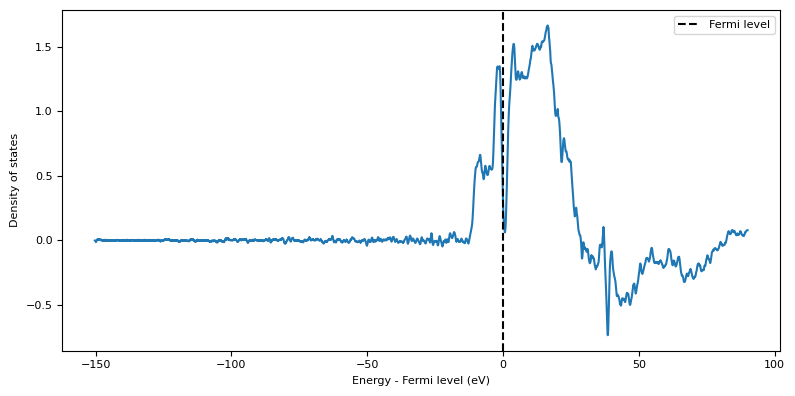

In [14]:
dos_calculator = None
try:
    silicon = bulk("Si", crystalstructure="diamond", a=5.43)
    dos_calculator = mlipstudio.create_calculator(
        "PET-MAD-DOS",
        device="cpu",
    )
    dos_result = mlipstudio.BandGapDOSTask().calculate(
        silicon,
        dos_calculator,
    )

    print(f"Band gap: {dos_result.band_gap_eV:.6f} eV")
    print(f"Fermi level: {dos_result.fermi_level_eV:.6f} eV")
    plt.figure(figsize=(8, 4))
    plt.plot(
        dos_result.energies_relative_to_fermi_eV,
        dos_result.density_of_states,
    )
    plt.axvline(0.0, color="black", linestyle="--", label="Fermi level")
    plt.xlabel("Energy - Fermi level (eV)")
    plt.ylabel("Density of states")
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("PET-MAD-DOS example could not run in this session.")
    print(type(exc).__name__, exc)
finally:
    if dos_calculator is not None:
        del dos_calculator
        release_unused_resources()

## 10. Where to go next

All task objects follow the same pattern: configure the task, then call `task.calculate(atoms, calculator)`. Results contain raw numerical arrays/scalars in documented ASE units and calculator-free copies of structures.

This notebook covered:

- `SinglePointTask`
- `OptimizationTask`
- `AtomizationCohesiveEnergyTask` for both cohesive and atomization energy
- `HOMOLUMOGapTask`
- `DipoleMomentTask`
- `SpinDeterminationTask`
- `BandGapDOSTask`

Use `mlipstudio.list_models()` and `mlipstudio.get_model_spec(name)` for programmatic discovery. Reuse a loaded calculator sequentially when possible, but create independent calculators for parallel workers or future NEB image calculations.